In [61]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.model_selection import train_test_split ,cross_val_score, cross_val_predict , GridSearchCV ,RandomizedSearchCV
from sklearn.ensemble import GradientBoostingClassifier ,RandomForestClassifier 
from xgboost import XGBClassifier 
from sklearn.metrics import accuracy_score ,f1_score,confusion_matrix ,ConfusionMatrixDisplay ,recall_score ,precision_recall_curve, roc_auc_score ,roc_curve,classification_report,precision_score,auc
from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.preprocessing import OneHotEncoder, RobustScaler ,StandardScaler , FunctionTransformer ,PowerTransformer 
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
import optuna

In [3]:
'''
numrical column :

    account_balance - > highly right skewed,
    transaction_amount -> high right skewed,
    customer_age -> little bit right skwed but it look litle bit normal distribution,
    account_age_year -> rigtht skwed
    credit_score-> left skewd but little bit
    total_transection = Normal Distributed 
    distance_from_home_km-> right skwed ,
    time_since_last_txn_hrs-> right skwed 

Catgory column :

    merchant_category -> ['Grocery', 'Healthcare', 'Utilities', 'Clothing',
        'Crypto Exchange', 'Education', 'Online Shopping', 'Jewelry',
        'Electronics', 'ATM Withdrawal', 'Fuel', 'Restaurant', 'Travel',
        'Entertainment', 'Gaming'] uniqe catagory  15
    payment_method - > num of payment methods are 6 ['Bank Transfer', 'Cheque', 'Crypto', 'Debit Card', 'Credit Card',
        'Mobile Payment'],
    device_type -> ['POS Terminal', 'Desktop', 'Mobile', 'ATM', 'Tablet']
    
    
1.     how to check multicollinerity 
2. 
'''


"\nnumrical column :\n\n    account_balance - > highly right skewed,\n    transaction_amount -> high right skewed,\n    customer_age -> little bit right skwed but it look litle bit normal distribution,\n    account_age_year -> rigtht skwed\n    credit_score-> left skewd but little bit\n    total_transection = Normal Distributed \n    distance_from_home_km-> right skwed ,\n    time_since_last_txn_hrs-> right skwed \n\nCatgory column :\n\n    merchant_category -> ['Grocery', 'Healthcare', 'Utilities', 'Clothing',\n        'Crypto Exchange', 'Education', 'Online Shopping', 'Jewelry',\n        'Electronics', 'ATM Withdrawal', 'Fuel', 'Restaurant', 'Travel',\n        'Entertainment', 'Gaming'] uniqe catagory  15\n    payment_method - > num of payment methods are 6 ['Bank Transfer', 'Cheque', 'Crypto', 'Debit Card', 'Credit Card',\n        'Mobile Payment'],\n    device_type -> ['POS Terminal', 'Desktop', 'Mobile', 'ATM', 'Tablet']\n\n\n1.     how to check multicollinerity \n2. \n"

In [4]:
df = pd.read_csv('csv/bank_fraud_cleaned_data.csv')
df.head()

,hour_of_day,is_weekend,is_night_transaction,merchant_category,payment_method,device_type,customer_age,credit_score,account_age_years,account_balance,transaction_amount,distance_from_home_km,time_since_last_txn_hrs,is_international,failed_attempts,pin_changed_recently,is_fraud,total_transactions
0,21,0,0,Grocery,Bank Transfer,POS Terminal,18,695,7.2,369.36,39.49,52.7,10.20,0,0,0,0,180
1,5,0,1,Healthcare,Cheque,Desktop,30,600,8.6,2681.99,153.71,0.9,12.47,0,0,0,0,176
2,12,0,0,Grocery,Crypto,Mobile,20,711,10.8,44590.64,118.20,9.2,0.08,0,1,0,0,181
3,2,0,1,Utilities,Debit Card,Mobile,29,711,7.3,1213.37,49.50,14.8,17.94,1,0,1,1,185
4,12,0,0,Clothing,Debit Card,Desktop,49,751,11.8,34615.01,30.74,38.9,2.16,0,0,0,0,152


In [5]:
df = df.drop(['distance_from_home_km'],axis=1)
df.head()

,hour_of_day,is_weekend,is_night_transaction,merchant_category,payment_method,device_type,customer_age,credit_score,account_age_years,account_balance,transaction_amount,time_since_last_txn_hrs,is_international,failed_attempts,pin_changed_recently,is_fraud,total_transactions
0,21,0,0,Grocery,Bank Transfer,POS Terminal,18,695,7.2,369.36,39.49,10.20,0,0,0,0,180
1,5,0,1,Healthcare,Cheque,Desktop,30,600,8.6,2681.99,153.71,12.47,0,0,0,0,176
2,12,0,0,Grocery,Crypto,Mobile,20,711,10.8,44590.64,118.20,0.08,0,1,0,0,181
3,2,0,1,Utilities,Debit Card,Mobile,29,711,7.3,1213.37,49.50,17.94,1,0,1,1,185
4,12,0,0,Clothing,Debit Card,Desktop,49,751,11.8,34615.01,30.74,2.16,0,0,0,0,152


In [6]:
X = df.drop(columns='is_fraud')
y = df['is_fraud']

In [66]:

X_sample, _, y_sample, _ = train_test_split(X, y, train_size=0.2, stratify=y)
 
X_train, x_test, Y_train, y_test = train_test_split(
    X_sample, y_sample, test_size=0.2, stratify=y_sample, random_state=42
)

In [8]:
X_train.shape,x_test.shape

((160000, 16), (40000, 16))

In [9]:
Y_train.value_counts()

is_fraud
0    151159
1      8841
Name: count, dtype: int64

In [10]:
y_test.value_counts()

is_fraud
0    37790
1     2210
Name: count, dtype: int64

## Preprocessing

In [11]:
# num_column 
Num_column = ['hour_of_day','customer_age','credit_score','account_age_years','account_balance','transaction_amount','time_since_last_txn_hrs','total_transactions']
print(f'Numrical_columns : \n {Num_column} ')

Numrical_columns : 
 ['hour_of_day', 'customer_age', 'credit_score', 'account_age_years', 'account_balance', 'transaction_amount', 'time_since_last_txn_hrs', 'total_transactions'] 


In [12]:
# Binarry columns
binary_column = ['is_weekend','is_night_transaction','is_international','failed_attempts','pin_changed_recently']
binary_column

['is_weekend',
 'is_night_transaction',
 'is_international',
 'failed_attempts',
 'pin_changed_recently']

In [13]:
# Categorical column 
Cat_column = X_train.select_dtypes(['object']).columns
len(Cat_column) # total column are num + cat = 14 + 3 = 17 

3

In [14]:
Num_pip = Pipeline([
    ('Missing Impute',SimpleImputer(strategy='median')),
    ('Transfome',PowerTransformer()),
    ('Scaler',RobustScaler())
])
Binary_pip = Pipeline([
    ('Missing Impute',SimpleImputer(strategy='most_frequent'))
])
Cat_pip = Pipeline([
    ('Missing Impute',SimpleImputer(strategy='most_frequent')),
    ('Encoding',OneHotEncoder(drop='first',handle_unknown='ignore',sparse_output=False))
])

In [15]:
# Combine_all_column Together 
preprocessing = ColumnTransformer([
    ('Num Pip',Num_pip,Num_column),
    ('Cat Pip',Cat_pip,Cat_column),
    ('Binnary Column',Binary_pip,binary_column)
])

In [16]:
preprocessing

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('Num Pip', ...), ('Cat Pip', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_n

In [52]:
pip  = Pipeline([
    ('Preprocessing',preprocessing),
    ('Model',RandomForestClassifier(n_estimators=100,max_depth=10,class_weight='balanced',random_state=42))
])   


In [53]:
pip.fit(X_train,Y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('Preprocessing', ...), ('Model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('Num Pip', ...), ('Cat Pip', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different t

In [54]:
y_pred = pip.predict(x_test)

In [58]:
print('Classification Report : \n',classification_report(y_test,y_pred))

Classification Report : 
               precision    recall  f1-score   support

           0       0.97      0.69      0.81     37790
           1       0.10      0.60      0.17      2210

    accuracy                           0.69     40000
   macro avg       0.53      0.64      0.49     40000
weighted avg       0.92      0.69      0.77     40000



In [59]:
# Confusion Matrix
confusion_matrix(y_test,y_pred)

array([[26155, 11635],
       [  889,  1321]])

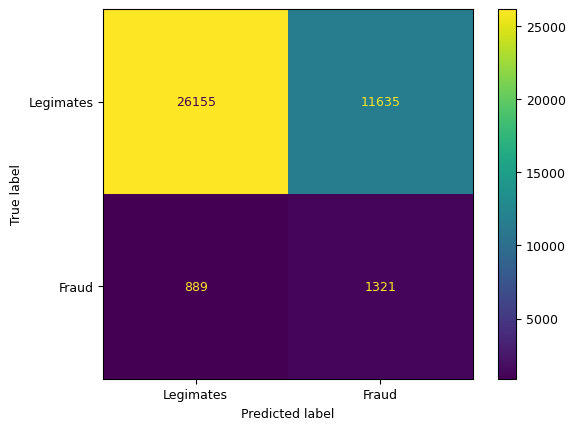

In [57]:
# Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test,y_pred,display_labels=['Legimates','Fraud'])

In [ ]:
# Overfiiting and underfitting check 

train_pred = pip.predict(X_train)
train_f1 = f1_score(Y_train, train_pred)

# Score on data it NEVER saw
val_pred = pip.predict(x_test)
val_f1 = f1_score(y_test, val_pred)

gap = train_f1 - val_f1
print(f"Train F1: {train_f1:.4f}")
print(f"Val F1:   {val_f1:.4f}")
print(f"Gap:      {gap:.4f}")

Train F1: 0.2157
Val F1:   0.1742
Gap:      0.0415


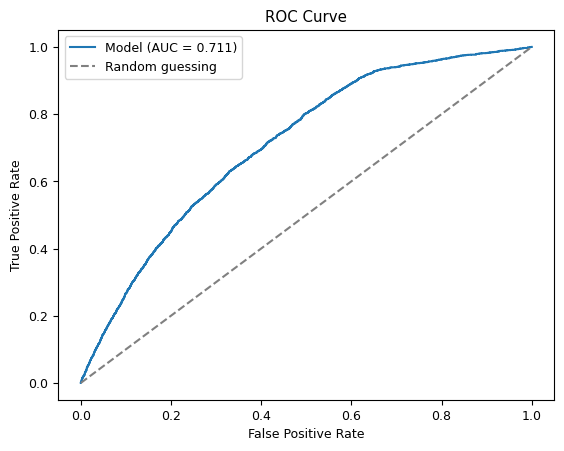

In [65]:
# Roc curve 
probs = pip.predict_proba(x_test)[:,1]
fpr,tpr ,thr = roc_curve(y_test,probs)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f'Model (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random guessing')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()
